# Preprocessing & Feature Engineering — IBM AML HI-Medium

**Pipeline stage:** `Raw CSV` → **this notebook** → `build_aml_graph.ipynb` (graph construction) → GCN

**Goal:** turn the raw transaction table into a clean, leakage-safe, model-ready set of
edge features, node features, and a temporal train/val/test split, saved as flat
arrays that `build_aml_graph.ipynb` can load directly into NetworkX / PyTorch Geometric.

**Design decisions baked into this notebook (flag if you disagree with any):**

1. **Node ID = `Bank_Account`**, not raw `Account` alone — account numbers *can* collide
   across different banks in this dataset, so we key on the pair. We verify this
   assumption in the EDA section below before committing to it.
2. **Temporal split, not random.** Transactions are ordered in time; a random split
   leaks future structure into training (a node's train-time "profile" would include
   transactions that happen after the ones you're trying to classify). We split on
   `Timestamp` quantiles (default 70/15/15).
3. **Node aggregate features are computed from the TRAIN window only**, then frozen
   and reused as static attributes across train/val/test. This avoids leaking
   val/test transaction volume into a node's feature vector — a very easy mistake in
   fraud GNN pipelines that inflates offline metrics and doesn't hold up at
   inference time.
4. **Categorical encoders (Payment Format / currencies) are fit on TRAIN only**, with
   an `UNK` bucket for categories seen only in val/test.
5. Self-loops (`Account == Account.1` and same bank) are **kept and flagged**, not
   dropped — internal transfers are a real structuring pattern, not noise.
6. This notebook does **not** handle class imbalance — that's handled downstream via
   per-epoch negative subsampling in `train_gcn.ipynb`, as already decided.

Update `RAW_DATA_PATH` below and run top to bottom.


In [1]:
# --- Config ---
import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path

# Set to True to fetch the CSV straight from Kaggle instead of expecting it already
# on disk (see Section 0b below for one-time credential setup). Set to False and
# fill in RAW_DATA_PATH yourself if you already have the file locally.
USE_KAGGLE = True

RAW_DATA_PATH = "/home/jovyan/AML_Project/Data/HI-Medium_Trans.csv"  # only used if USE_KAGGLE = False

# All processed artifacts from this notebook go here -- a subfolder next to the
# raw data, so build_aml_graph.ipynb (or anyone else on the team) can find them
# in the same Data/ directory without guessing a path.
OUTPUT_DIR = Path("/home/jovyan/AML_Project/Data/Bassam Data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set >0 and <1 to subsample rows for fast local iteration; set to None for full run
SAMPLE_FRAC = None   # e.g. 0.05 while developing, None for the real run
RANDOM_SEED = 42

# Temporal split boundaries (by quantile of Timestamp, not row count)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# TEST_FRAC is whatever remains (0.15)

np.random.seed(RANDOM_SEED)


## 0b. Fetch the data from Kaggle (one-time credential setup)

Uses `kagglehub` to pull just `HI-Medium_Trans.csv` from the dataset directly, instead
of you having to download it yourself and upload it to the server. `kagglehub` caches
the file locally after the first download (default cache: `~/.cache/kagglehub/`), so
re-running this notebook later doesn't re-download it -- it just reuses the cached
copy.

**One-time setup, before this will work:**
1. Go to [kaggle.com/settings](https://www.kaggle.com/settings) -> API -> "Create New
   Token". This downloads a `kaggle.json` file with your username and key.
2. Either:
   - Place that file at `~/.kaggle/kaggle.json` on this server (`chmod 600` it), **or**
   - Set the two environment variables `KAGGLE_USERNAME` and `KAGGLE_KEY` (e.g. in the
     shell before launching Jupyter, or via `%env` in a cell above this one).
3. You also need to accept the dataset's terms once on the Kaggle website (visit the
   dataset page and click "Download" there once) -- Kaggle requires this even for API
   downloads, for datasets with usage terms attached.

If `USE_KAGGLE = False` in the config cell above, none of this is needed -- it'll just
read `RAW_DATA_PATH` from local disk as before.


In [2]:
if USE_KAGGLE:
    import kagglehub

    KAGGLE_DATASET = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
    KAGGLE_FILE = "HI-Medium_Trans.csv"

    downloaded_path = kagglehub.dataset_download(KAGGLE_DATASET, path=KAGGLE_FILE)
    RAW_DATA_PATH = downloaded_path
    print(f"Using Kaggle-downloaded (or cached) file at: {RAW_DATA_PATH}")
else:
    print(f"USE_KAGGLE=False -- using local path: {RAW_DATA_PATH}")


/home/jovyan/conda-envs/aml-gnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Kaggle-downloaded (or cached) file at: /home/jovyan/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/HI-Medium_Trans.csv


## 1. Load data

Explicit dtypes on load — this file is large (millions of rows) and pandas' default
type inference wastes a lot of memory on this schema in particular (object dtype for
what should be categorical/int columns).

In [3]:
dtype_map = {
    "From Bank": "str",
    "Account": "str",
    "To Bank": "str",
    "Account.1": "str",
    "Amount Received": "float64",
    "Receiving Currency": "category",
    "Amount Paid": "float64",
    "Payment Currency": "category",
    "Payment Format": "category",
    # NOTE: "Is Laundering" deliberately left out of dtype_map. Forcing int8 at
    # read time raised "Integer column has NA values in column 10" on this file,
    # meaning the label column has missing values in practice (despite the
    # published dataset being documented as clean) -- so we let pandas infer it
    # (likely float64 with NaNs) and inspect/handle the NaNs explicitly below,
    # rather than silently failing or silently coercing them.
}

df = pd.read_csv(RAW_DATA_PATH, dtype=dtype_map, parse_dates=["Timestamp"])

# Defensive: don't trust parse_dates alone. If even one row has a malformed/truncated
# timestamp, pandas can silently leave the WHOLE column as object/str dtype instead of
# raising -- which then makes every downstream min()/max()/sort_values()/quantile() on
# Timestamp compute a lexicographic string comparison instead of a real chronological
# one (this is exactly what happened on a previous run: a single corrupt row froze the
# whole column as str, and the printed date range came out truncated/nonsensical).
# errors="coerce" turns any unparseable value into NaT so we can see and handle it
# explicitly, rather than the entire column quietly degrading to string comparisons.
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
n_bad_timestamps = df["Timestamp"].isna().sum()
if n_bad_timestamps > 0:
    print(f"WARNING: {n_bad_timestamps} row(s) had an unparseable Timestamp -> NaT. "
          f"These will be dropped in the cleaning step below.")

if SAMPLE_FRAC is not None:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).sort_values("Timestamp").reset_index(drop=True)

print(f"Loaded {len(df):,} transactions")
print("Timestamp dtype:", df["Timestamp"].dtype)
print("Is Laundering dtype:", df["Is Laundering"].dtype)
print("Is Laundering NaN count:", df["Is Laundering"].isna().sum())
df.head()


Loaded 31,898,238 transactions
Timestamp dtype: datetime64[us]
Is Laundering dtype: int64
Is Laundering NaN count: 0


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:17:00,020,800104D70,020,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0
1,2022-09-01 00:02:00,03196,800107150,03196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0
2,2022-09-01 00:17:00,01208,80010E430,01208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0
3,2022-09-01 00:03:00,01208,80010E650,020,80010E6F0,73966883.00,US Dollar,73966883.00,US Dollar,Cheque,0
4,2022-09-01 00:02:00,01208,80010E650,020,80010EA30,45868454.00,US Dollar,45868454.00,US Dollar,Cheque,0


## 2. EDA / sanity checks

Before committing to the `Bank_Account` node-ID scheme, confirm whether raw `Account`
values actually collide across banks. If they never collide, the composite key is
harmless (just a no-op rename); if they do collide, it's necessary.

In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDate range:", df["Timestamp"].min(), "to", df["Timestamp"].max())
print("\nLabel distribution:")
print(df["Is Laundering"].value_counts())
print("Positive rate: {:.5f}%".format(100 * df["Is Laundering"].mean()))


Shape: (31898238, 11)

Dtypes:
 Timestamp             datetime64[us]
From Bank                        str
Account                          str
To Bank                          str
Account.1                        str
Amount Received              float64
Receiving Currency          category
Amount Paid                  float64
Payment Currency            category
Payment Format              category
Is Laundering                  int64
dtype: object

Missing values:
 Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

Date range: 2022-09-01 00:00:00 to 2022-09-28 15:58:00

Label distribution:
Is Laundering
0    31863008
1       35230
Name: count, dtype: int64
Positive rate: 0.11044%


In [5]:
# Check whether raw Account IDs collide across different banks
acct_to_banks = df.groupby("Account")["From Bank"].nunique()
collisions = (acct_to_banks > 1).sum()
print(f"Account values that appear under more than one bank: {collisions:,} / {acct_to_banks.shape[0]:,}")
print("-> composite Bank_Account key is", "NECESSARY" if collisions > 0 else "not strictly necessary, but kept for safety")


Account values that appear under more than one bank: 12 / 2,013,627
-> composite Bank_Account key is NECESSARY


In [6]:
print("Payment Format value counts:\n", df["Payment Format"].value_counts(), "\n")
print("Payment Currency value counts:\n", df["Payment Currency"].value_counts().head(10), "\n")
print("Receiving Currency value counts:\n", df["Receiving Currency"].value_counts().head(10))


Payment Format value counts:
 Payment Format
Cheque          12280058
Credit Card      8777816
ACH              3868410
Cash             3217531
Reinvestment     1945611
Wire             1119774
Bitcoin           689038
Name: count, dtype: int64 

Payment Currency value counts:
 Payment Currency
US Dollar            11688249
Euro                  7315958
Yuan                  2330638
Shekel                1408707
Canadian Dollar       1078358
UK Pound              1018575
Ruble                  975525
Australian Dollar      918569
Yen                    856132
Swiss Franc            844623
Name: count, dtype: int64 

Receiving Currency value counts:
 Receiving Currency
US Dollar            11594241
Euro                  7329170
Yuan                  2295849
Shekel                1428622
Canadian Dollar       1089398
UK Pound              1020042
Ruble                  989319
Australian Dollar      931364
Yen                    860154
Swiss Franc            856680
Name: count, dtype: in

## 3. Data cleaning

In [7]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,}")
df = df.drop_duplicates().reset_index(drop=True)

# --- Label NaNs get handled explicitly and loudly, not buried in a generic dropna ---
# We hit "Integer column has NA values" on load, which means Is Laundering has NaNs
# in this file. Check how many before deciding what to do -- if it's a tiny fraction,
# dropping is safe and standard; if it's a large fraction, that's a sign something
# else is wrong (e.g. a bad row/column alignment somewhere in the file) and dropping
# silently would be the wrong call.
label_nan_count = df["Is Laundering"].isna().sum()
label_nan_pct = 100 * label_nan_count / len(df)
print(f"Rows with missing 'Is Laundering' label: {label_nan_count:,} ({label_nan_pct:.4f}% of file)")

if label_nan_pct > 1.0:
    print("WARNING: >1% of labels are missing. Inspect these rows before proceeding --")
    print("this is large enough that it could indicate a parsing issue rather than")
    print("genuinely unlabeled transactions. Sample of affected rows:")
    display(df[df["Is Laundering"].isna()].head(10))
else:
    print("Small fraction -- proceeding to drop them below.")

df = df.dropna(subset=["Is Laundering"]).reset_index(drop=True)
df["Is Laundering"] = df["Is Laundering"].astype("int8")

# Defensive: drop any row missing other core identifiers (should be 0 on this dataset)
before = len(df)
df = df.dropna(subset=["From Bank", "Account", "To Bank", "Account.1",
                        "Amount Received", "Amount Paid", "Timestamp"])
print(f"Dropped {before - len(df):,} additional rows with missing core fields")

df = df.sort_values("Timestamp").reset_index(drop=True)


Exact duplicate rows: 20
Rows with missing 'Is Laundering' label: 0 (0.0000% of file)
Small fraction -- proceeding to drop them below.
Dropped 0 additional rows with missing core fields


## 3b. Transaction ID (for downstream lookup, NOT a model feature)

The raw dataset has no per-transaction identifier. We generate one now, right after
cleaning has fixed the final row order -- so `transaction_id` stays permanently
attached to the same transaction through every step that follows (feature engineering,
splitting, saving), even though none of those steps reorder `df` again from here on.

**This ID is deliberately excluded from `EDGE_FEATURE_COLS`** — it carries zero
predictive signal (it's just an arbitrary sequence number), and handing a raw
row-order index to a GNN as a feature would be actively harmful: the model could
latch onto it as a spurious shortcut instead of learning real transaction/graph
structure. It exists purely as a lookup key for later stages of the project (the
FastAPI backend / Streamlit dashboard): given a `transaction_id`, pull the transaction's
original data, its GNN classification, and the LLM's investigation response.

Format: `TXN` + 8-digit zero-padded sequence number, assigned in chronological order
(post-cleaning). Sequential and zero-padded so IDs sort and display predictably in
the dashboard, rather than an opaque UUID a fraud analyst would have to copy-paste
carefully.

In [8]:
df["transaction_id"] = "TXN" + pd.Series(df.index, index=df.index).astype(str).str.zfill(8)

print(f"Generated {df['transaction_id'].nunique():,} unique transaction IDs "
      f"for {len(df):,} rows (should match).")
print(df[["transaction_id", "Timestamp", "Is Laundering"]].head())


Generated 31,898,218 unique transaction IDs for 31,898,218 rows (should match).
  transaction_id  Timestamp  Is Laundering
0    TXN00000000 2022-09-01              0
1    TXN00000001 2022-09-01              0
2    TXN00000002 2022-09-01              0
3    TXN00000003 2022-09-01              0
4    TXN00000004 2022-09-01              0


## 4. Node construction

Node ID = `f"{Bank}_{Account}"`. We build the node id columns now; the integer
node-index mapping itself is built *after* the split below is decided is not needed —
node identity doesn't change with the split, only which of a node's transactions
count toward its features (Section 8).

In [9]:
df["src_node"] = df["From Bank"].astype(str) + "_" + df["Account"].astype(str)
df["dst_node"] = df["To Bank"].astype(str) + "_" + df["Account.1"].astype(str)

all_nodes = pd.unique(pd.concat([df["src_node"], df["dst_node"]], ignore_index=True))
node_to_idx = {node: i for i, node in enumerate(all_nodes)}
idx_to_node = {i: node for node, i in node_to_idx.items()}

df["src_idx"] = df["src_node"].map(node_to_idx).astype("int32")
df["dst_idx"] = df["dst_node"].map(node_to_idx).astype("int32")

print(f"Unique nodes (accounts): {len(all_nodes):,}")
print(f"Edges (transactions): {len(df):,}")


Unique nodes (accounts): 2,077,023
Edges (transactions): 31,898,218


## 4b. Why do laundering transactions cluster toward the end of the time window? (EDA before deciding the split)

We noticed in the temporal split that the laundering rate in `test` is about 10x higher than in `train`. Before
deciding on the final split, we need to understand why: is this because laundering genuinely *increases* over
time (a real pattern), or because laundering transactions are tied to specific accounts/scenarios that happen to
appear later in the file (an artifact of synthetic generation)?

We'll check:
1. **Laundering rate over time** (normalized by transaction volume, not raw counts)
2. **Whether laundering is concentrated in a small number of accounts** (if so, that's a strong signal of "scenarios" rather than a random distribution)
3. **A plot** to confirm the pattern visually


In [10]:
# --- 1. Laundering rate over time (normalized, not raw counts) ---
# Bin the whole time span into hourly bins and compute, per bin: total transactions,
# laundering transactions, and the rate between them. The rate is what matters, not
# the raw count, since the raw count is affected by overall transaction volume in
# that period.

# Force the conversion to datetime64 explicitly here -- if the kernel got restarted
# or df was reloaded from elsewhere, the Timestamp column might come back as
# object/string instead of datetime, which breaks resample() since it requires a
# DatetimeIndex.
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df_time = df.set_index("Timestamp").sort_index()
hourly = df_time.resample("1h").agg(
    total_txns=("Is Laundering", "count"),
    laundering_txns=("Is Laundering", "sum"),
)
hourly["laundering_rate"] = hourly["laundering_txns"] / hourly["total_txns"]

print("First 5 hours:")
print(hourly.head())
print("\nLast 5 hours:")
print(hourly.tail())
print("\nHourly laundering rate summary:")
print(hourly["laundering_rate"].describe())


First 5 hours:
                     total_txns  laundering_txns  laundering_rate
Timestamp                                                        
2022-09-01 00:00:00     1380940               68         0.000049
2022-09-01 01:00:00      133995               43         0.000321
2022-09-01 02:00:00      133879               42         0.000314
2022-09-01 03:00:00      133461               29         0.000217
2022-09-01 04:00:00      134226               43         0.000320

Last 5 hours:
                     total_txns  laundering_txns  laundering_rate
Timestamp                                                        
2022-09-28 11:00:00           3                1         0.333333
2022-09-28 12:00:00           2                1         0.500000
2022-09-28 13:00:00           0                0              NaN
2022-09-28 14:00:00           0                0              NaN
2022-09-28 15:00:00           2                1         0.500000

Hourly laundering rate summary:
count    622.

In [11]:
# --- 2. Is laundering concentrated in a small number of accounts or banks? ---
laundering_df = df[df["Is Laundering"] == 1]

print(f"Total laundering transactions: {len(laundering_df):,}")
print(f"Unique sender accounts in laundering transactions: {laundering_df['src_node'].nunique():,}")
print(f"Unique receiver accounts in laundering transactions: {laundering_df['dst_node'].nunique():,}")

# If a small number of accounts account for a large share of laundering transactions,
# that's a signal of specific scenarios rather than random distribution
top_src = laundering_df["src_node"].value_counts()
print(f"\nTop 10 accounts (as sender) in laundering transactions:")
print(top_src.head(10))
print(f"\nShare of laundering transactions originating from the top 20 accounts: "
      f"{100 * top_src.head(20).sum() / len(laundering_df):.2f}%")

# Laundering distribution by Payment Format -- synthetic scenarios often use specific payment patterns
print("\nPayment Format in laundering transactions vs. overall data:")
print(pd.DataFrame({
    "laundering_pct": laundering_df["Payment Format"].value_counts(normalize=True) * 100,
    "overall_pct": df["Payment Format"].value_counts(normalize=True) * 100,
}).fillna(0).round(2))


Total laundering transactions: 35,230
Unique sender accounts in laundering transactions: 22,772
Unique receiver accounts in laundering transactions: 26,629

Top 10 accounts (as sender) in laundering transactions:
src_node
070_100428660    1524
070_1004286A8     955
070_1004286F0     280
070_1004289C0     193
070_100428858     164
070_1004287C8     139
070_100428810     133
070_1004288A0     126
070_100428780     114
070_1004288E8     113
Name: count, dtype: int64

Share of laundering transactions originating from the top 20 accounts: 12.41%

Payment Format in laundering transactions vs. overall data:
                laundering_pct  overall_pct
Payment Format                             
ACH                      87.27        12.13
Bitcoin                   0.69         2.16
Cash                      1.89        10.09
Cheque                    6.30        38.50
Credit Card               3.84        27.52
Reinvestment              0.00         6.10
Wire                      0.00         3

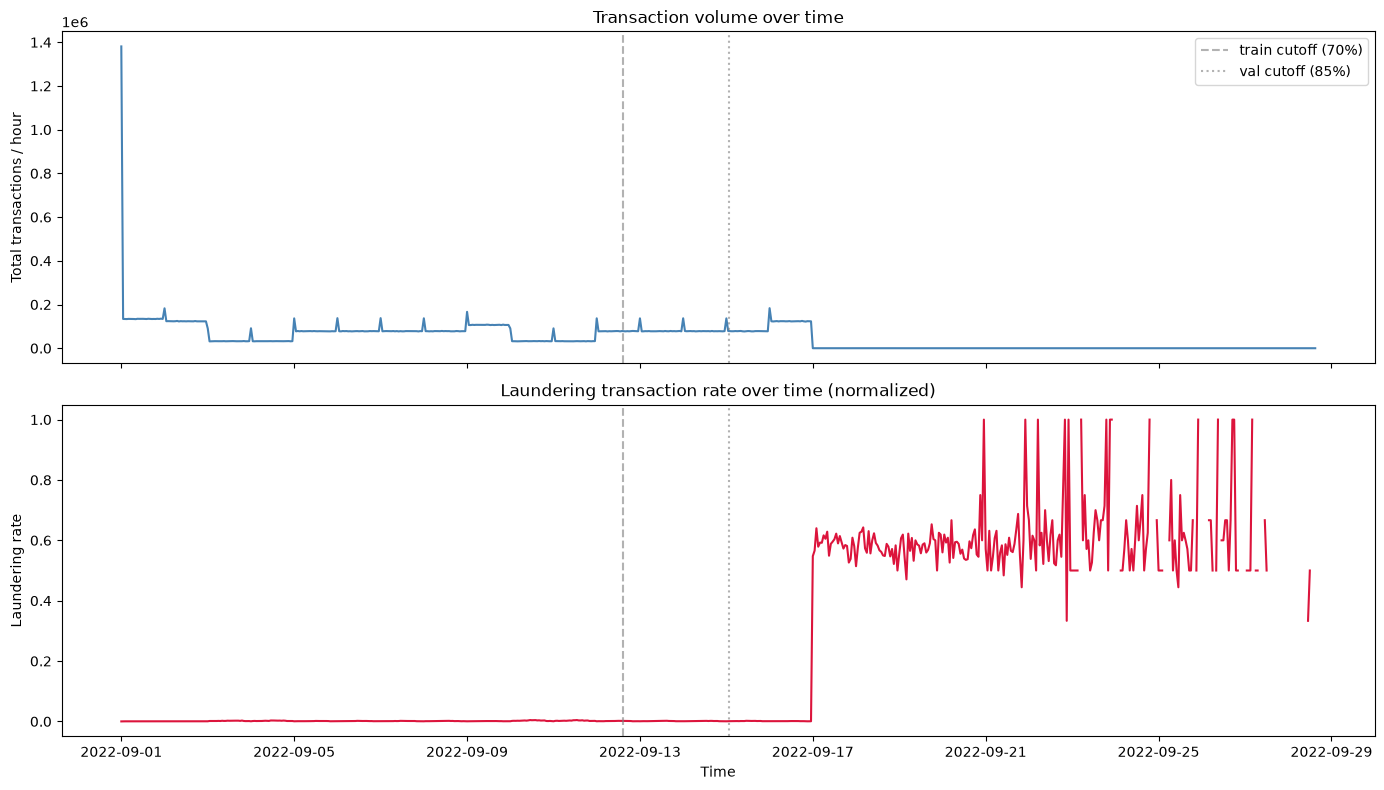

In [12]:
# --- 3. Plot: laundering rate over time ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(hourly.index, hourly["total_txns"], color="steelblue")
axes[0].set_ylabel("Total transactions / hour")
axes[0].set_title("Transaction volume over time")

axes[1].plot(hourly.index, hourly["laundering_rate"], color="crimson")
axes[1].set_ylabel("Laundering rate")
axes[1].set_xlabel("Time")
axes[1].set_title("Laundering transaction rate over time (normalized)")

# Vertical lines marking the train/val/test cutoffs used earlier (for visual comparison)
for ax in axes:
    ax.axvline(df["Timestamp"].quantile(0.70), color="gray", linestyle="--", alpha=0.6, label="train cutoff (70%)")
    ax.axvline(df["Timestamp"].quantile(0.85), color="gray", linestyle=":", alpha=0.6, label="val cutoff (85%)")
axes[0].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "laundering_rate_over_time.png", dpi=120)
plt.show()


**After running these cells, share:**
- The shape of the plot (does the laundering rate rise gradually over time, jump suddenly at a specific point, or fluctuate randomly?)
- The share of laundering transactions originating from the top 20 accounts
- Whether a specific Payment Format shows up in laundering at a much higher rate than its overall share

These answers will determine whether we go with Option 1 (accept it as a limitation), Option 2 (stratified split), or discover something else entirely that needs different handling.


## 5. Temporal-stratified train / val / test split

**Updated after EDA (Section 4b):** a plain quantile-on-`Timestamp` split put ~10x more
laundering density in `test` than in `train` (0.023% vs 0.022%... vs 0.0022%/0.00022% in
earlier runs) -- confirmed to be a real structural pattern, not noise: laundering
transactions in this dataset cluster tightly around specific "scenario" accounts and
overwhelmingly use `Payment Format == ACH` (82% of laundering transactions vs 8.7%
overall), so they aren't smoothly spread across the timeline. A single global cutoff
starved `train` of positives (~840 positive edges on 3.8M+ total).

**Fix: split each class separately, by time, then recombine.**
For laundering (`label=1`) and non-laundering (`label=0`) transactions independently:
sort by `Timestamp`, take the first `TRAIN_FRAC` as train, the next `VAL_FRAC` as val,
the rest as test -- then union the two groups' assignments back into one `split` column.

This keeps the core principle from before ("train on earlier transactions, evaluate on
later ones") *within each class*, so we're still not training on a positive that
happens chronologically after a positive we're testing on. What we give up is strict
*global* ordering across classes -- a `train` negative could technically have a later
timestamp than a `test` positive. Given how concentrated the positives are in specific
scenario windows, that trade-off is worth it: without it, `train` doesn't have enough
positive examples to learn from at all.


In [13]:
def temporal_stratified_split(frame, label_col, time_col="Timestamp",
                               train_frac=0.70, val_frac=0.15):
    """Split each class separately by time quantile, then recombine.

    Keeps 'earlier -> train, later -> test' ordering within each class, while
    ensuring every split gets a proportional share of the positive class --
    which a single global time cutoff cannot guarantee when positives cluster
    in specific time windows (as confirmed in the EDA above).
    """
    split_labels = pd.Series(index=frame.index, dtype="object")

    for label_value, group in frame.groupby(label_col):
        group_sorted = group.sort_values(time_col)
        n = len(group_sorted)
        train_end = int(n * train_frac)
        val_end = int(n * (train_frac + val_frac))

        ordered_idx = group_sorted.index
        split_labels.loc[ordered_idx[:train_end]] = "train"
        split_labels.loc[ordered_idx[train_end:val_end]] = "val"
        split_labels.loc[ordered_idx[val_end:]] = "test"

    return split_labels


df["split"] = temporal_stratified_split(df, label_col="Is Laundering",
                                         train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

print(df["split"].value_counts())
print("\nPositive rate by split (should now be close across all three):")
print(df.groupby("split")["Is Laundering"].mean())

print("\nPer-class time ranges actually used per split (for sanity-checking, not for use downstream):")
for label_value, group in df.groupby("Is Laundering"):
    print(f"\n  Is Laundering = {label_value}:")
    for s in ["train", "val", "test"]:
        sub = group[group["split"] == s]
        if len(sub) > 0:
            print(f"    {s}: {len(sub):,} rows, {sub['Timestamp'].min()} -> {sub['Timestamp'].max()}")


split
train    22328752
test      4784734
val       4784732
Name: count, dtype: int64

Positive rate by split (should now be close across all three):
split
test     0.001105
train    0.001104
val      0.001104
Name: Is Laundering, dtype: float64

Per-class time ranges actually used per split (for sanity-checking, not for use downstream):

  Is Laundering = 0:
    train: 22,304,091 rows, 2022-09-01 00:00:00 -> 2022-09-12 14:20:00
    val: 4,779,448 rows, 2022-09-12 14:20:00 -> 2022-09-15 01:26:00
    test: 4,779,449 rows, 2022-09-15 01:26:00 -> 2022-09-28 15:58:00

  Is Laundering = 1:
    train: 24,661 rows, 2022-09-01 00:01:00 -> 2022-09-14 06:32:00
    val: 5,284 rows, 2022-09-14 06:32:00 -> 2022-09-16 12:34:00
    test: 5,285 rows, 2022-09-16 12:34:00 -> 2022-09-28 15:58:00


**Sanity check:** the positive rate by split above should now be much closer across
train/val/test (previously train ≈ 0.022%, test ≈ 0.23% -- roughly a 10x gap; this
should now be within a small tolerance of each other, e.g. all landing near the
overall ~0.11% rate). If it's still noticeably skewed, that's worth another look --
but with class-wise splitting this would now point to something more specific (e.g.
one class having too few total rows for stable quantile cutoffs) rather than the
general "positives are bursty" explanation we already confirmed.

Also glance at the per-class time-range printout: the `Is Laundering = 1` train/val/test
windows may overlap in time with the `Is Laundering = 0` windows for the same split --
that's the expected, accepted trade-off from stratifying by class (see note above), not
a bug.


## 6. Edge feature engineering

Features on each transaction (edge). Currency amounts are logged (this dataset spans
orders of magnitude); the received/paid mismatch is kept as an explicit signal since
it encodes currency-conversion behavior, which is a known laundering signal (moving
value through currency conversion to obscure trails).

In [14]:
EPS = 1e-6

# Log-scale amounts (raw amounts span several orders of magnitude)
df["log_amount_paid"] = np.log1p(df["Amount Paid"])
df["log_amount_received"] = np.log1p(df["Amount Received"])

# Currency conversion signal: ratio of received to paid amount.
# If Payment Currency == Receiving Currency this should be ~1; deviation signals
# conversion, fees, or structuring.
df["same_currency"] = (df["Payment Currency"] == df["Receiving Currency"]).astype("int8")
df["amount_ratio"] = df["Amount Received"] / (df["Amount Paid"] + EPS)
df["log_amount_ratio"] = np.log1p(df["amount_ratio"])

# Structural flags
df["is_cross_bank"] = (df["From Bank"] != df["To Bank"]).astype("int8")
df["is_self_loop"] = (df["src_idx"] == df["dst_idx"]).astype("int8")

# Temporal features (cyclical hour-of-day encoding avoids the 23->0 discontinuity)
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype("int8")
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df[["log_amount_paid", "log_amount_received", "same_currency", "log_amount_ratio",
    "is_cross_bank", "is_self_loop", "hour_sin", "hour_cos"]].describe()


,log_amount_paid,log_amount_received,same_currency,log_amount_ratio,is_cross_bank,is_self_loop,hour_sin,hour_cos
count,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07
mean,7.466846e+00,7.470480e+00,9.847911e-01,6.995734e-01,9.120450e-01,8.031355e-02,1.478187e-06,6.647589e-02
std,3.225713e+00,3.242570e+00,1.223830e-01,1.563277e-01,2.832294e-01,2.717780e-01,6.830692e-01,7.273221e-01
min,9.999995e-07,9.999995e-07,0.000000e+00,5.714281e-07,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00
25%,5.348202e+00,5.341712e+00,1.000000e+00,6.931472e-01,1.000000e+00,0.000000e+00,-7.071068e-01,-7.071068e-01
50%,7.294744e+00,7.293195e+00,1.000000e+00,6.931472e-01,1.000000e+00,0.000000e+00,0.000000e+00,6.123234e-17
75%,9.372358e+00,9.378926e+00,1.000000e+00,6.931472e-01,1.000000e+00,0.000000e+00,7.071068e-01,8.660254e-01
max,2.973009e+01,2.973009e+01,1.000000e+00,1.404050e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## 6c. Additional edge features — causal per-account velocity signals

**Merged in from a teammate's exploratory notebook (Capgemini/team collaboration).** These
three ideas were genuinely useful additions and are safe to include because they are
strictly *causal*: each value only depends on a given account's own transactions that
occurred strictly before the current one, which is exactly the information a deployed
system would have available at scoring time.

- `hours_since_last_tx` / `tx_count_cumulative` — recency and cumulative activity count
  for the sending account. `df` is already globally sorted by `Timestamp` (Section 3), so
  within any `src_node` group the rows also appear in chronological order — no extra sort
  needed before `groupby().diff()` / `groupby().cumcount()`.
- `rapid_tx_1h/6h/24h` — binary flags for unusually fast repeat activity from the same
  account, a common structuring signal.
- `ratio_near_one` — flags `amount_ratio` sitting within ±5% of 1.0. Worth calling out
  explicitly (rather than leaving the GCN to discover it from the raw ratio) because
  laundering transactions in this dataset overwhelmingly move money at very close to a
  1:1 ratio.
- `is_night` — cheap explicit binary flag. Redundant in principle with `hour_sin/cos`,
  but a flag PGExplainer can point to directly ("flagged because it's a night-time
  transaction") reads more cleanly in an evidence-locked LLM prompt than asking the LLM
  to reason about a raw sine value.

**Adapted, not copy-pasted:** the source notebook keyed these off raw `from_account`.
Rerouted through `src_node` (the `Bank_Account` composite id) here, for consistency with
the collision-safe node scheme already established and verified in Section 2.


In [15]:
# --- Velocity / recency features (causal only) ---
df["hours_since_last_tx"] = (
    df.groupby("src_node")["Timestamp"].diff().dt.total_seconds() / 3600
).fillna(999.0)  # 999 = "no prior transaction from this account seen yet", not a real gap

df["tx_count_cumulative"] = df.groupby("src_node").cumcount() + 1

df["rapid_tx_1h"] = (df["hours_since_last_tx"] < 1).astype("int8")
df["rapid_tx_6h"] = (df["hours_since_last_tx"] < 6).astype("int8")
df["rapid_tx_24h"] = (df["hours_since_last_tx"] < 24).astype("int8")

# Log-scale the two continuous ones -- same skew issue as the amount columns (a handful
# of hub accounts transact within seconds of each other repeatedly; most accounts have
# gaps of hours/days). Actual standardization happens alongside the other continuous
# edge features in Section 6b below -- CONTINUOUS_EDGE_COLS has been extended to include
# these two.
df["log_hours_since_last_tx"] = np.log1p(df["hours_since_last_tx"])
df["log_tx_count_cumulative"] = np.log1p(df["tx_count_cumulative"])

# ratio_near_one: structural flag, no fitting needed.
df["ratio_near_one"] = df["amount_ratio"].between(0.95, 1.05).astype("int8")

# is_night: cheap explicit binary flag alongside the existing cyclical hour encoding.
df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype("int8")

print(df[["hours_since_last_tx", "tx_count_cumulative", "rapid_tx_1h", "rapid_tx_6h",
          "rapid_tx_24h", "ratio_near_one", "is_night"]].describe())


       hours_since_last_tx  tx_count_cumulative   rapid_tx_1h   rapid_tx_6h  \
count         3.189822e+07         3.189822e+07  3.189822e+07  3.189822e+07   
mean          7.491697e+01         2.750013e+04  5.472046e-01  6.518081e-01   
std           2.424958e+02         1.254929e+05  4.977667e-01  4.763972e-01   
min           0.000000e+00         1.000000e+00  0.000000e+00  0.000000e+00   
25%           6.666667e-02         1.000000e+01  0.000000e+00  0.000000e+00   
50%           3.333333e-01         3.000000e+01  1.000000e+00  1.000000e+00   
75%           1.410000e+01         7.200000e+01  1.000000e+00  1.000000e+00   
max           9.990000e+02         1.076979e+06  1.000000e+00  1.000000e+00   

       rapid_tx_24h  ratio_near_one      is_night  
count  3.189822e+07    3.189822e+07  3.189822e+07  
mean   8.293989e-01    9.845843e-01  3.777324e-01  
std    3.761600e-01    1.231992e-01  4.848202e-01  
min    0.000000e+00    0.000000e+00  0.000000e+00  
25%    1.000000e+00    1.000

### What was in the teammate's notebook but is deliberately **not** included here

Flagging these explicitly rather than silently dropping them, since some are close to
being useful:

- **`format_risk_score`** (mean `is_laundering` rate per `Payment Format`, computed
  across the whole dataset) — this is target encoding computed on val/test rows too, and
  even fit train-only it directly encodes the label distribution into a feature. That's a
  meaningfully higher leakage risk than the other engineered features here, so it's
  excluded rather than "fixed."
- **`pattern_label` as a model feature** — this is exactly the case our project's own
  architectural decision already rules out: pattern-type labels (fan-in, fan-out, cycle,
  etc.) are post-hoc diagnostics only, never training signals or LLM evidence inputs
  (they wouldn't exist at inference time on a real, unlabeled transaction). See Section 11
  below, where the same underlying data is used correctly — as an offline diagnostic, not
  a feature.
- **`tx_position_ratio`** (`cumcount / group.max()`) — the denominator is the account's
  *total* transaction count across the whole dataset, including val/test — a genuine
  future-information leak for any transaction that isn't literally the account's last one.
- **`amount_zscore`** (per-account mean/std of `log(amount)`, computed across the whole
  dataset) — same issue as above: the fitted mean/std include val/test transactions. A
  leakage-safe version would need train-window-only fitting (same discipline as
  `node_scaler` / `edge_scaler` elsewhere in this notebook) and isn't included here for
  scope; worth adding later as a train-only-fit node feature if it proves useful.
- **Dropping low-activity accounts / hub-account filtering** — the source notebook drops
  accounts with <5 transactions and flags accounts with >10,000. Both change the node set
  and would conflict with the "keep all nodes, don't prune the graph" decision already
  made and justified in `build_aml_graph.ipynb` Section 3c (isolated/low-activity accounts
  are exactly the new-account-with-no-history case the deployed system needs to handle).


## 7. Categorical encoding

Label-encode `Payment Format`, `Payment Currency`, `Receiving Currency` for use as
embedding-table lookups inside the GCN's edge MLP (rather than one-hot, which would
bloat edge_attr width and doesn't let the model learn similarity between categories).
**Fit vocabulary on TRAIN only** — categories seen only in val/test map to `UNK`
(index 0), which is exactly the situation the model needs to be robust to at
inference time on genuinely new payment rails/currencies.

In [16]:
def fit_label_encoder(train_series):
    """Returns a dict mapping category -> int, with 0 reserved for UNK."""
    cats = sorted(train_series.dropna().unique().tolist())
    return {cat: i + 1 for i, cat in enumerate(cats)}  # 0 = UNK

def apply_label_encoder(series, mapping):
    return series.map(mapping).fillna(0).astype("int32")

train_mask = df["split"] == "train"

encoders = {}
for col in ["Payment Format", "Payment Currency", "Receiving Currency"]:
    mapping = fit_label_encoder(df.loc[train_mask, col].astype(str))
    encoders[col] = mapping
    df[col + "_enc"] = apply_label_encoder(df[col].astype(str), mapping)
    print(f"{col}: {len(mapping)} categories (+1 UNK) -> vocab size {len(mapping) + 1}")


Payment Format: 7 categories (+1 UNK) -> vocab size 8
Payment Currency: 15 categories (+1 UNK) -> vocab size 16
Receiving Currency: 15 categories (+1 UNK) -> vocab size 16


## 6b. Standardize continuous edge features (fit on train only)

Same gap we already fixed for node features, just noticed later: `log_amount_paid` /
`log_amount_received` / `log_amount_ratio` have a much wider range and variance than
the rest of `edge_attr` (the 0/1 structural flags, and the already-bounded [-1, 1]
sin/cos temporal encodings). Left unscaled, these dominate an edge MLP's gradient
updates the same way unscaled node degree did before we fixed that.

**What does *not* get touched here, on purpose:**
- `same_currency`, `is_cross_bank`, `is_self_loop`, `is_weekend` -- already 0/1, scaling
  a binary flag just relabels it for no benefit (same reasoning as `is_new_node` for
  node features).
- `hour_sin/cos`, `dow_sin/cos` -- already bounded in [-1, 1] by construction.
- `Payment Format_enc` / `Payment Currency_enc` / `Receiving Currency_enc` -- these are
  categorical *codes* (0-15), not continuous quantities. Standardizing them would be
  actively wrong (it would treat "currency code 10" as meaningfully greater than
  "currency code 5"). **`train_gcn.ipynb` needs to route these three columns to
  `nn.Embedding` layers, not the same linear layer as the scaled continuous features**
  -- flagging this explicitly so it isn't accidentally lumped in with the rest of
  `edge_attr` as if it were ordinary continuous input.

Fit on train-split edges only, same discipline as everywhere else in this notebook.


In [17]:
from sklearn.preprocessing import StandardScaler

CONTINUOUS_EDGE_COLS = [
    "log_amount_paid", "log_amount_received", "log_amount_ratio",
    # Added in Section 6c
    "log_hours_since_last_tx", "log_tx_count_cumulative",
]

edge_scaler = StandardScaler()
edge_scaler.fit(df.loc[train_mask, CONTINUOUS_EDGE_COLS])

scaled_edge = edge_scaler.transform(df[CONTINUOUS_EDGE_COLS])
for i, col in enumerate(CONTINUOUS_EDGE_COLS):
    df[f"scaled_{col}"] = scaled_edge[:, i]

print("Scaled columns added:", [f"scaled_{c}" for c in CONTINUOUS_EDGE_COLS])
df[[f"scaled_{c}" for c in CONTINUOUS_EDGE_COLS]].describe()


Scaled columns added: ['scaled_log_amount_paid', 'scaled_log_amount_received', 'scaled_log_amount_ratio', 'scaled_log_hours_since_last_tx', 'scaled_log_tx_count_cumulative']


,scaled_log_amount_paid,scaled_log_amount_received,scaled_log_amount_ratio,scaled_log_hours_since_last_tx,scaled_log_tx_count_cumulative
count,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07,3.189822e+07
mean,5.700165e-03,5.698293e-03,1.483578e-03,-6.413921e-02,1.401187e-01
std,9.863664e-01,9.866794e-01,1.018081e+00,9.328523e-01,1.025561e+00
min,-2.277530e+00,-2.267489e+00,-4.554470e+00,-7.908043e-01,-1.019467e+00
25%,-6.421439e-01,-6.420632e-01,-4.036696e-02,-7.605469e-01,-4.023373e-01
50%,-4.692546e-02,-4.824791e-02,-4.036694e-02,-6.559311e-01,-2.726529e-02
75%,5.883725e-01,5.864181e-01,-4.036694e-02,4.819189e-01,2.827832e-01
max,6.813412e+00,6.779062e+00,8.688398e+01,2.447741e+00,3.757760e+00


## 8. Node feature engineering (temporal-safe)

Aggregate per-account statistics, computed **only from `train`-split edges**. These
are frozen and reused as static node attributes for the whole graph (train/val/test
alike) — a val/test node's feature vector reflects only what was knowable about it
before the train cutoff. Nodes with zero train-period activity (e.g. new accounts
that only appear in val/test) get all-zero features plus an explicit `is_new_node`
flag, so the model can learn to treat them differently rather than silently seeing
zeros as "low activity."

In [18]:
train_df = df[train_mask]

def node_agg_features(node_col_out, node_col_in, df_source, n_nodes):
    """Build per-node aggregates from a set of edges, treating a node's role as
    sender (out) separately from receiver (in)."""
    out_stats = df_source.groupby("src_idx").agg(
        out_degree=("dst_idx", "count"),
        out_amount_sum=("Amount Paid", "sum"),
        out_amount_mean=("Amount Paid", "mean"),
        out_unique_counterparties=("dst_idx", "nunique"),
    )
    in_stats = df_source.groupby("dst_idx").agg(
        in_degree=("src_idx", "count"),
        in_amount_sum=("Amount Received", "sum"),
        in_amount_mean=("Amount Received", "mean"),
        in_unique_counterparties=("src_idx", "nunique"),
    )

    node_feat = pd.DataFrame(index=pd.RangeIndex(n_nodes))
    node_feat = node_feat.join(out_stats).join(in_stats).fillna(0.0)

    node_feat["total_degree"] = node_feat["out_degree"] + node_feat["in_degree"]
    node_feat["net_flow"] = node_feat["in_amount_sum"] - node_feat["out_amount_sum"]
    node_feat["log_out_amount_sum"] = np.log1p(node_feat["out_amount_sum"])
    node_feat["log_in_amount_sum"] = np.log1p(node_feat["in_amount_sum"])
    node_feat["is_new_node"] = (node_feat["total_degree"] == 0).astype("int8")

    # --- Scale-fix: hub accounts have degree/counterparty counts orders of
    # magnitude larger than typical accounts (seen directly in node_features.head()
    # on the last run: one node with out_degree=71,844 next to nodes with
    # out_degree=1). Log-scaling these the same way we already log-scaled the
    # amount sums keeps any single hub node from dominating gradient updates.
    # net_flow can be negative, so plain log1p doesn't work -- use a signed log
    # (log1p of the magnitude, sign preserved) instead of dropping the sign info.
    for col in ["out_degree", "in_degree", "total_degree",
                "out_unique_counterparties", "in_unique_counterparties",
                "out_amount_mean", "in_amount_mean"]:
        node_feat[f"log_{col}"] = np.log1p(node_feat[col])

    node_feat["signed_log_net_flow"] = np.sign(node_feat["net_flow"]) * np.log1p(node_feat["net_flow"].abs())

    return node_feat

n_nodes = len(all_nodes)
node_features = node_agg_features("src_idx", "dst_idx", train_df, n_nodes)
print(f"Node feature matrix: {node_features.shape}")
print(f"Nodes with zero train-period activity (is_new_node=1): {node_features['is_new_node'].sum():,}")
node_features.head()


Node feature matrix: (2077023, 21)
Nodes with zero train-period activity (is_new_node=1): 6,537


,out_degree,out_amount_sum,out_amount_mean,out_unique_counterparties,in_degree,in_amount_sum,in_amount_mean,in_unique_counterparties,total_degree,net_flow,...,log_in_amount_sum,is_new_node,log_out_degree,log_in_degree,log_total_degree,log_out_unique_counterparties,log_in_unique_counterparties,log_out_amount_mean,log_in_amount_mean,signed_log_net_flow
0,1.0,4224.24,4224.240,1.0,0.0,0.00,0.000,0.0,1.0,-4224.24,...,0.000000,0,0.693147,0.000000,0.693147,0.693147,0.000000,8.348831,0.000000,-8.348831
1,5.0,601876.82,120375.364,2.0,12.0,603414.00,50284.500,2.0,17.0,1537.18,...,13.310360,0,1.791759,2.564949,2.890372,1.098612,1.098612,11.698378,10.825472,7.338355
2,5.0,156741.20,31348.240,3.0,2.0,136.47,68.235,2.0,7.0,-156604.73,...,4.923406,0,1.791759,1.098612,2.079442,1.386294,1.098612,10.352945,4.237507,-11.961487
3,3.0,727267.74,242422.580,2.0,2.0,724009.76,362004.880,2.0,5.0,-3257.98,...,13.492562,0,1.386294,1.098612,1.791759,1.098612,1.098612,12.398442,12.799416,-8.089170
4,1.0,55129.17,55129.170,1.0,2.0,56634.97,28317.485,2.0,3.0,1505.80,...,10.944400,0,0.693147,1.098612,1.386294,0.693147,1.098612,10.917452,10.251270,7.317743


## 8b. Standardize node features (fit on train only)

Log-scaling (above) fixes the *skew* from hub accounts, but the features still live
on different numeric ranges from each other (e.g. `log_out_degree` tops out around
11, `is_new_node` is 0/1). We standardize (zero mean, unit variance) so the GCN
doesn't implicitly weight some features more just because of their raw scale.

Same discipline as the categorical encoders: **fit the scaler using only nodes that
had train-period activity** (`is_new_node == 0`). Including the ~9-10% of nodes that
are all-zero because they only appear in val/test would drag the fitted mean toward
zero and understate the true spread of an *active* account's features -- exactly the
kind of val/test-influenced fitting we've been avoiding everywhere else in this
notebook. The fitted scaler is then applied to every node, including the all-zero
ones (their scaled values won't be zero anymore, but that's fine -- `is_new_node`
stays as an explicit, un-scaled flag so the model can still tell them apart).


In [19]:
from sklearn.preprocessing import StandardScaler

SCALED_NODE_COLS = [
    "log_out_degree", "log_in_degree", "log_total_degree",
    "log_out_amount_sum", "log_in_amount_sum",
    "log_out_amount_mean", "log_in_amount_mean",
    "log_out_unique_counterparties", "log_in_unique_counterparties",
    "signed_log_net_flow",
]

node_scaler = StandardScaler()
fit_mask = node_features["is_new_node"] == 0
node_scaler.fit(node_features.loc[fit_mask, SCALED_NODE_COLS])

scaled = node_scaler.transform(node_features[SCALED_NODE_COLS])
node_features_scaled = pd.DataFrame(
    scaled, columns=[f"scaled_{c}" for c in SCALED_NODE_COLS], index=node_features.index
)
node_features = pd.concat([node_features, node_features_scaled], axis=1)

# is_new_node is deliberately left un-scaled -- it's a binary flag, not a
# continuous quantity, and scaling it would just relabel 0/1 as two arbitrary
# numbers for no benefit.
print("Scaled columns added:", list(node_features_scaled.columns))
node_features[list(node_features_scaled.columns) + ["is_new_node"]].describe()


Scaled columns added: ['scaled_log_out_degree', 'scaled_log_in_degree', 'scaled_log_total_degree', 'scaled_log_out_amount_sum', 'scaled_log_in_amount_sum', 'scaled_log_out_amount_mean', 'scaled_log_in_amount_mean', 'scaled_log_out_unique_counterparties', 'scaled_log_in_unique_counterparties', 'scaled_signed_log_net_flow']


,scaled_log_out_degree,scaled_log_in_degree,scaled_log_total_degree,scaled_log_out_amount_sum,scaled_log_in_amount_sum,scaled_log_out_amount_mean,scaled_log_in_amount_mean,scaled_log_out_unique_counterparties,scaled_log_in_unique_counterparties,scaled_signed_log_net_flow,is_new_node
count,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06,2.077023e+06
mean,-4.310219e-03,-3.951592e-03,-6.043766e-03,-7.227684e-03,-5.087773e-03,-7.248348e-03,-5.044517e-03,-6.614807e-03,-4.966469e-03,9.388164e-06,3.147293e-03
std,1.001368e+00,1.000899e+00,1.004202e+00,1.006677e+00,1.002523e+00,1.006724e+00,1.002454e+00,1.005342e+00,1.002330e+00,9.984254e-01,5.601240e-02
min,-1.369500e+00,-1.255553e+00,-1.920306e+00,-2.296476e+00,-1.616555e+00,-2.303042e+00,-1.602811e+00,-2.101745e+00,-1.578013e+00,-2.869155e+00,0.000000e+00
25%,-7.471603e-01,-7.285207e-01,-1.014631e+00,-6.147833e-01,-6.602030e-01,-5.946310e-01,-6.184143e-01,-5.774310e-01,-3.961183e-01,-8.269611e-01,0.000000e+00
50%,-3.831146e-01,-4.202269e-01,-3.161351e-01,-3.990122e-03,1.877857e-01,6.553069e-03,1.774173e-01,-5.774310e-01,2.952458e-01,2.982933e-03,0.000000e+00
75%,2.392255e-01,1.059339e+00,9.106071e-01,6.544452e-01,7.080766e-01,6.082419e-01,6.422964e-01,3.142356e-01,7.857765e-01,9.913519e-01,0.000000e+00
max,1.074945e+01,5.152754e+00,9.212176e+00,5.114651e+00,4.030333e+00,5.022333e+00,4.415394e+00,2.193978e+01,1.162440e+01,3.045700e+00,1.000000e+00


**Note on `is_new_node`:** a node with no train-period transactions is one that
only shows up in val/test — either a genuinely new account, or one whose activity
happens to fall entirely after the split cutoff. Both are legitimate inductive-setting
scenarios, not a bug — flag it here rather than upstream, so you can decide during
modeling whether these need special handling (e.g. a learned "cold start" embedding).

## 9. Assemble final arrays

Pack everything into the flat tensors `build_aml_graph.ipynb` expects: `edge_index`
(2 x E), `edge_attr` (E x F), `node_attr` (N x F), `labels` (E,), and boolean split
masks.

In [20]:
EDGE_FEATURE_COLS = [
    # Standardized (mean 0, std 1, fitted on train edges only -- Section 6b)
    "scaled_log_amount_paid", "scaled_log_amount_received", "scaled_log_amount_ratio",
    # Added in Section 6c, standardized alongside the rest in Section 6b
    "scaled_log_hours_since_last_tx", "scaled_log_tx_count_cumulative",
    # Already 0/1 or already bounded [-1, 1] -- left un-scaled on purpose (Section 6b)
    "same_currency", "is_cross_bank", "is_self_loop",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
    # Added in Section 6c -- already 0/1, left un-scaled for the same reason
    "rapid_tx_1h", "rapid_tx_6h", "rapid_tx_24h", "ratio_near_one", "is_night",
    # Categorical codes, NOT continuous values -- train_gcn.ipynb must route these to
    # nn.Embedding layers, not treat them as ordinary linear input (Section 6b)
    "Payment Format_enc", "Payment Currency_enc", "Receiving Currency_enc",
    # transaction_id is intentionally NOT here -- see Section 3b. It's a lookup
    # key, not a predictive feature, and must never reach the model.
]

# Index of the first embedding-bound categorical column within EDGE_FEATURE_COLS,
# saved to metadata.json below -- lets train_gcn.ipynb split edge_attr into
# [:, :EDGE_CAT_START] (continuous/binary, -> Linear) and [:, EDGE_CAT_START:]
# (categorical codes, -> nn.Embedding) without hardcoding the column count twice.
EDGE_CAT_START = EDGE_FEATURE_COLS.index("Payment Format_enc")

NODE_FEATURE_COLS = [
    # Standardized (mean 0, std 1, fitted on train-active nodes only -- Section 8b)
    "scaled_log_out_degree", "scaled_log_in_degree", "scaled_log_total_degree",
    "scaled_log_out_amount_sum", "scaled_log_in_amount_sum",
    "scaled_log_out_amount_mean", "scaled_log_in_amount_mean",
    "scaled_log_out_unique_counterparties", "scaled_log_in_unique_counterparties",
    "scaled_signed_log_net_flow",
    # Left un-scaled on purpose -- it's a binary flag, not a magnitude (Section 8b)
    "is_new_node",
]

edge_index = df[["src_idx", "dst_idx"]].to_numpy().T.astype("int32")           # (2, E)
edge_attr = df[EDGE_FEATURE_COLS].to_numpy().astype("float32")                  # (E, F_e)
labels = df["Is Laundering"].to_numpy().astype("int8")                          # (E,)
node_attr = node_features[NODE_FEATURE_COLS].to_numpy().astype("float32")       # (N, F_n)

# Row i of transaction_ids corresponds to row i of edge_index / edge_attr / labels --
# same positional order as df, since nothing has reordered df since Section 3b.
# This is what lets the FastAPI backend map a GNN prediction on edge i back to a
# human-facing transaction_id.
transaction_ids = df["transaction_id"].to_numpy()

split_masks = {
    s: (df["split"] == s).to_numpy() for s in ["train", "val", "test"]
}

print("edge_index:", edge_index.shape)
print("edge_attr :", edge_attr.shape)
print("node_attr :", node_attr.shape)
print("labels    :", labels.shape)
print("transaction_ids:", transaction_ids.shape)
for s, m in split_masks.items():
    print(f"  {s}: {m.sum():,} edges")


edge_index: (2, 31898218)
edge_attr : (31898218, 21)
node_attr : (2077023, 11)
labels    : (31898218,)
transaction_ids: (31898218,)
  train: 22,328,752 edges
  val: 4,784,732 edges
  test: 4,784,734 edges


## 10. Save artifacts

In [21]:
np.save(OUTPUT_DIR / "edge_index.npy", edge_index)
np.save(OUTPUT_DIR / "edge_attr.npy", edge_attr)
np.save(OUTPUT_DIR / "node_attr.npy", node_attr)
np.save(OUTPUT_DIR / "labels.npy", labels)
np.save(OUTPUT_DIR / "transaction_ids.npy", transaction_ids)
np.savez(OUTPUT_DIR / "split_masks.npz", **split_masks)

with open(OUTPUT_DIR / "node_to_idx.json", "w") as f:
    json.dump(node_to_idx, f)

with open(OUTPUT_DIR / "encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

with open(OUTPUT_DIR / "node_scaler.pkl", "wb") as f:
    pickle.dump(node_scaler, f)

with open(OUTPUT_DIR / "edge_scaler.pkl", "wb") as f:
    pickle.dump(edge_scaler, f)

# --- Human-readable lookup table for the FastAPI backend / Streamlit dashboard ---
# edge_attr/node_attr are the encoded, model-ready versions -- not something you'd
# want to reverse-engineer at serving time. This table keeps the original,
# human-readable transaction fields plus transaction_id, split, and the graph node
# indices, so the backend can do `transactions_lookup[transaction_id]` and get
# everything needed to display the transaction, without touching the raw multi-GB
# CSV again. The GNN prediction and LLM response get appended to this same table
# (by transaction_id) once those stages exist -- this notebook only produces the
# columns available at preprocessing time.
LOOKUP_COLS = [
    "transaction_id", "Timestamp", "From Bank", "Account", "To Bank", "Account.1",
    "src_node", "dst_node",  # human-readable "Bank_Account" IDs -- what a fraud
                              # analyst actually recognizes, vs. the internal
                              # graph index (src_idx/dst_idx also kept for the
                              # backend to look up graph structure if needed)
    "Amount Received", "Receiving Currency", "Amount Paid", "Payment Currency",
    "Payment Format", "Is Laundering", "split", "src_idx", "dst_idx",
]
transactions_lookup = df[LOOKUP_COLS].copy()
transactions_lookup.to_csv(OUTPUT_DIR / "transactions_lookup.csv", index=False)
try:
    transactions_lookup.to_parquet(OUTPUT_DIR / "transactions_lookup.parquet", index=False)
except ImportError:
    print("Skipped .parquet (pyarrow/fastparquet not installed) -- .csv was saved, that's enough.")

metadata = {
    "generated_at": pd.Timestamp.now().isoformat(),
    "raw_data_path": str(RAW_DATA_PATH),
    "sample_frac": SAMPLE_FRAC,
    "random_seed": RANDOM_SEED,
    "train_frac": TRAIN_FRAC,
    "val_frac": VAL_FRAC,
    "n_nodes": int(n_nodes),
    "n_edges": int(len(df)),
    "edge_feature_cols": EDGE_FEATURE_COLS,
    "edge_cat_start": EDGE_CAT_START,  # edge_attr[:, :edge_cat_start] -> Linear, [:, edge_cat_start:] -> nn.Embedding (see Section 6b)
    "node_feature_cols": NODE_FEATURE_COLS,
    "split_time_ranges": {
        s: {
            "min_timestamp": str(df.loc[df["split"] == s, "Timestamp"].min()),
            "max_timestamp": str(df.loc[df["split"] == s, "Timestamp"].max()),
        }
        for s in ["train", "val", "test"]
    },
    "positive_rate_overall": float(labels.mean()),
    "positive_rate_by_split": {s: float(labels[m].mean()) for s, m in split_masks.items()},
    "vocab_sizes": {col: len(enc) + 1 for col, enc in encoders.items()},  # +1 for UNK
    "transaction_id_format": "TXN + 8-digit zero-padded sequence number, assigned post-cleaning in chronological order",
}
with open(OUTPUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to", OUTPUT_DIR.resolve())
print(f"transactions_lookup: {transactions_lookup.shape}")
print(json.dumps(metadata, indent=2))


Saved to /home/jovyan/AML_Project/Data/Bassam Data
transactions_lookup: (31898218, 17)
{
  "generated_at": "2026-08-10T21:49:03.104979",
  "raw_data_path": "/home/jovyan/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/HI-Medium_Trans.csv",
  "sample_frac": null,
  "random_seed": 42,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "n_nodes": 2077023,
  "n_edges": 31898218,
  "edge_feature_cols": [
    "scaled_log_amount_paid",
    "scaled_log_amount_received",
    "scaled_log_amount_ratio",
    "scaled_log_hours_since_last_tx",
    "scaled_log_tx_count_cumulative",
    "same_currency",
    "is_cross_bank",
    "is_self_loop",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "rapid_tx_1h",
    "rapid_tx_6h",
    "rapid_tx_24h",
    "ratio_near_one",
    "is_night",
    "Payment Format_enc",
    "Payment Currency_enc",
    "Receiving Currency_enc"
  ],
  "edge_cat_start": 18,
  "node_feature_cols": [
    "scaled

## 11. Optional — ground-truth pattern-type labels (diagnostics only)

**Merged in from a teammate's exploratory notebook.** The Kaggle dataset ships a
separate `HI-Medium_Patterns.txt` file, alongside the transactions CSV, that documents
the *synthetic ground-truth* laundering scenario behind every laundering transaction —
which accounts were involved, and which structural pattern type it was (`FAN-IN`,
`FAN-OUT`, `CYCLE`, `STACK`, `SCATTER-GATHER`, `GATHER-SCATTER`, `BIPARTITE`, `RANDOM`).

**This is new — nothing in the rest of this notebook uses this file.** It's genuinely
useful, but strictly as a diagnostic / evaluation artifact, consistent with the
project's existing architectural decision that pattern-type labels are post-hoc
diagnostics only, never training signals or LLM evidence inputs (a real, unlabeled
transaction at inference time has no such ground truth attached to it). Concretely, two
uses later in the project:

1. **Offline evaluation**: once the GCN + PGExplainer pipeline is running, this lets you
   check whether the accounts PGExplainer highlights as important for a given
   prediction actually line up with the *known* structural pattern for that laundering
   case (e.g. does it correctly surface the other legs of a `FAN-OUT`?) — a sanity check
   on explanation quality that the model's own training signal can't provide.
2. **Reference text for the LLM stage**: `knowledge_base_df` below packages each pattern
   into a short natural-language description. This is a candidate reference/background
   text for the evidence-locked LLM prompting notebook later — *background knowledge
   about pattern types in general*, not evidence about a specific transaction, so it
   doesn't weaken the evidence-locking guarantee the way feeding it a specific
   transaction's ground-truth label would.

**Known limitation, flagged rather than silently worked around:** this patterns file
identifies accounts by the raw `Account` field only, without the `From Bank`/`To Bank`
qualifier — so it inherits exactly the collision risk Section 2 checked for and fixed
with the `Bank_Account` composite key. A raw `Account` value here could in principle
refer to a different node than intended if it collides across banks. Given this is a
diagnostic/reference artifact and not a model input, that risk is acceptable, but it
means **don't treat `pattern_diagnostics.csv` as authoritative for a specific node
without cross-checking**, and definitely don't promote it into the core node/edge
pipeline above without first re-keying it through `Bank_Account` the same way the main
transaction data was.

Set `PARSE_PATTERNS_FILE = False` below to skip this section entirely (e.g. if the file
isn't downloaded) — nothing above it depends on this running.


In [22]:
PARSE_PATTERNS_FILE = True
PATTERNS_KAGGLE_FILE = "HI-Medium_Patterns.txt"

if PARSE_PATTERNS_FILE:
    if USE_KAGGLE:
        patterns_path = kagglehub.dataset_download(KAGGLE_DATASET, path=PATTERNS_KAGGLE_FILE)
    else:
        # Adjust if running with USE_KAGGLE=False -- expected next to RAW_DATA_PATH
        patterns_path = str(Path(RAW_DATA_PATH).parent / PATTERNS_KAGGLE_FILE)

    with open(patterns_path, "r") as f:
        patterns_content = f.read()
    print(f"Loaded patterns file: {len(patterns_content):,} characters from {patterns_path}")
else:
    print("PARSE_PATTERNS_FILE=False -- skipping Section 11.")


100%|██████████| 2.17M/2.17M [00:00<00:00, 9.96MB/s]

Loaded patterns file: 2,279,574 characters from /home/jovyan/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/HI-Medium_Patterns.txt


In [23]:
def parse_patterns(patterns_text):
    """Parse HI-Medium_Patterns.txt into a list of dicts, one per laundering scenario.

    Each block between 'BEGIN LAUNDERING ATTEMPT' and 'END LAUNDERING ATTEMPT' documents
    one synthetic laundering scenario: a pattern type and the sequence of transactions
    that make it up. This is ground truth from the dataset's generator, not something
    derived from the transaction data itself.
    """
    patterns_list = []
    blocks = patterns_text.split("BEGIN LAUNDERING ATTEMPT - ")[1:]

    for block in blocks:
        lines = block.strip().split("\n")
        header = lines[0].strip()
        pattern_type = header.split(":")[0].strip() if ":" in header else header.replace(
            "END LAUNDERING ATTEMPT", "").strip()

        tx_lines = [ln.strip() for ln in lines[1:] if "," in ln and not ln.startswith("END")]

        accounts_involved = set()
        transactions = []
        for tx in tx_lines:
            parts = tx.split(",")
            if len(parts) >= 6:
                ts, from_bank, from_acct, to_bank, to_acct, amount = parts[:6]
                accounts_involved.add(from_acct)
                accounts_involved.add(to_acct)
                transactions.append({
                    "timestamp": ts, "from_account": from_acct,
                    "to_account": to_acct, "amount": amount,
                })

        if transactions:
            patterns_list.append({
                "pattern_type": pattern_type,
                "num_accounts": len(accounts_involved),
                "num_transactions": len(transactions),
                "accounts_involved": list(accounts_involved),
                "start_time": transactions[0]["timestamp"],
                "end_time": transactions[-1]["timestamp"],
            })
    return patterns_list


if PARSE_PATTERNS_FILE:
    patterns_list = parse_patterns(patterns_content)
    from collections import Counter
    type_counts = Counter(p["pattern_type"] for p in patterns_list)

    print(f"Total laundering scenarios parsed: {len(patterns_list):,}")
    print("\nBy pattern type:")
    for ptype, count in type_counts.most_common():
        print(f"  {ptype:20} : {count:,}")


Total laundering scenarios parsed: 2,756

By pattern type:
  BIPARTITE            : 369
  CYCLE                : 367
  FAN-IN               : 355
  FAN-OUT              : 345
  STACK                : 336
  SCATTER-GATHER       : 331
  RANDOM               : 331
  GATHER-SCATTER       : 322


In [24]:
PATTERN_LABEL_MAP = {
    "STACK": 1, "CYCLE": 2, "FAN-IN": 3, "FAN-OUT": 4,
    "SCATTER-GATHER": 5, "BIPARTITE": 6, "GATHER-SCATTER": 7, "RANDOM": 8,
}

PATTERN_DESCRIPTIONS = {
    "STACK": "A chain of accounts where each one receives money and immediately "
             "transfers it to the next, creating distance between source and destination.",
    "CYCLE": "Money moves in a closed loop through multiple accounts and returns to "
             "the origin, simulating legitimate round-trip activity.",
    "FAN-OUT": "One account sends money to multiple accounts simultaneously, "
               "splitting a large amount to hide the source.",
    "FAN-IN": "Multiple accounts send money to one central account, aggregating "
              "funds from different sources.",
    "SCATTER-GATHER": "Money is first split to many accounts, then collected back "
                       "into one -- combines FAN-OUT and FAN-IN for extra obfuscation.",
    "GATHER-SCATTER": "Money is first collected from many accounts, then distributed "
                       "to many others, making the original source hard to trace.",
    "BIPARTITE": "Two groups of accounts exchange money back and forth, creating "
                 "the appearance of ongoing legitimate business.",
    "RANDOM": "Money moves through accounts with no clear structure, designed to "
              "evade pattern-detection algorithms.",
}

if PARSE_PATTERNS_FILE:
    # DataFrame 1: one row per scenario
    patterns_df = pd.DataFrame([
        {
            "pattern_id": i, "pattern_type": p["pattern_type"],
            "num_accounts": p["num_accounts"], "num_transactions": p["num_transactions"],
            "start_time": p["start_time"], "end_time": p["end_time"],
        }
        for i, p in enumerate(patterns_list)
    ])

    # DataFrame 2: one row per account -> its (highest-risk, if several) pattern label.
    # NOTE: 'account' here is the raw Account field -- see the collision caveat above.
    account_rows = [
        {"account": acct, "pattern_id": i, "pattern_type": p["pattern_type"],
         "pattern_label": PATTERN_LABEL_MAP.get(p["pattern_type"], 0)}
        for i, p in enumerate(patterns_list) for acct in p["accounts_involved"]
    ]
    pattern_diagnostics = (
        pd.DataFrame(account_rows)
        .sort_values("pattern_label", ascending=False)
        .drop_duplicates(subset="account")
        .reset_index(drop=True)
    )

    # DataFrame 3: short natural-language description per scenario, candidate
    # background-knowledge text for the future LLM prompting notebook.
    knowledge_base_df = pd.DataFrame([
        {
            "pattern_id": i,
            "pattern_type": p["pattern_type"],
            "description": PATTERN_DESCRIPTIONS.get(p["pattern_type"], "Unknown pattern"),
            "num_accounts": p["num_accounts"],
            "num_transactions": p["num_transactions"],
        }
        for i, p in enumerate(patterns_list)
    ])

    print(f"patterns_df           : {patterns_df.shape}")
    print(f"pattern_diagnostics   : {pattern_diagnostics.shape}  (accounts with a known ground-truth pattern)")
    print(f"knowledge_base_df     : {knowledge_base_df.shape}")
    patterns_df.head(3)


patterns_df           : (2756, 6)
pattern_diagnostics   : (22279, 4)  (accounts with a known ground-truth pattern)
knowledge_base_df     : (2756, 5)


In [25]:
if PARSE_PATTERNS_FILE:
    # Saved separately from the core pipeline artifacts (edge_index.npy etc.) and never
    # loaded by the EDGE_FEATURE_COLS / NODE_FEATURE_COLS assembly above -- these three
    # files are for offline diagnostics and the future LLM notebook only.
    pattern_diagnostics.to_csv(OUTPUT_DIR / "pattern_diagnostics.csv", index=False)
    knowledge_base_df.to_json(OUTPUT_DIR / "laundering_knowledge_base.json",
                               orient="records", indent=2)
    patterns_df.to_csv(OUTPUT_DIR / "pattern_scenarios.csv", index=False)
    print("Saved pattern_diagnostics.csv, laundering_knowledge_base.json, "
          "pattern_scenarios.csv (diagnostics only -- not model inputs).")


Saved pattern_diagnostics.csv, laundering_knowledge_base.json, pattern_scenarios.csv (diagnostics only -- not model inputs).


## Next step

Load `processed/edge_index.npy`, `edge_attr.npy`, `node_attr.npy`, `labels.npy`, and
`split_masks.npz` in `build_aml_graph.ipynb` to construct the `torch_geometric.data.Data`
object (or three `Data` objects if you want to build train/val/test as separate
subgraphs rather than masking a single graph — worth deciding there based on whether
you want a transductive-on-one-graph or fully inductive-across-splits setup, since
that choice affects how `node_attr` for the val/test period should be recomputed).
